# ⚽ Gaussian Mixture Model (GMM) — Gaya Bermain Klub La Liga

---

## 📋 Deskripsi Notebook

Notebook ini merupakan tahap **Machine Learning** lanjutan dalam penelitian skripsi Data Engineering yang menganalisis gaya bermain klub-klub La Liga.

**Tujuan:**
- Mengelompokkan 20 klub La Liga berdasarkan **10 style scores** menggunakan **Gaussian Mixture Model (GMM)**.
- Menonjolkan keunggulan GMM sebagai **soft clustering** — setiap klub memiliki **probabilitas keanggotaan** pada setiap cluster, sehingga satu klub dapat memiliki karakteristik beberapa gaya bermain sekaligus.
- Menghasilkan interpretasi yang lebih kaya dibandingkan K-Means: bukan hanya "klub ini masuk cluster X", tetapi "klub ini 60% cluster X dan 35% cluster Y".

**Input:**
- File `data/ml_ready/teams_style_scores.csv` — dataset hasil notebook Style Scoring.

**Output:**
- Cluster utama setiap klub
- Probabilitas keanggotaan setiap klub pada seluruh cluster
- Visualisasi cluster & probabilitas
- Interpretasi karakteristik setiap cluster
- Perbandingan dengan K-Means

---

### 🔑 Mengapa GMM?

Dalam sepakbola, gaya bermain sebuah tim **tidak selalu murni satu kategori**. Sebuah tim bisa 70% *possession-based* dan 30% *pressing-oriented*. K-Means memaksa setiap tim masuk ke **satu** cluster saja (*hard clustering*), sedangkan GMM memberikan **probabilitas** keanggotaan pada setiap cluster (*soft clustering*).

Ini lebih merepresentasikan realita sepakbola modern dimana tim-tim top sering mengadopsi elemen taktis dari berbagai filosofi bermain.

> ⚠️ Notebook ini **tidak mengulang** proses feature engineering. Data sudah siap dari notebook Style Scoring sebelumnya.

---

## 1. Import Library

In [1]:
# === Data Manipulation ===
import numpy as np
import pandas as pd
from pathlib import Path

# === Visualization ===
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# === Machine Learning ===
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# === Settings ===
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

RANDOM_STATE = 42

print("✅ Semua library berhasil diimpor.")

✅ Semua library berhasil diimpor.


---

## 2. Load Dataset

In [2]:
# --- Load Dataset ---
PROJECT_ROOT = Path.cwd().parent
data_path = PROJECT_ROOT / "data" / "ml_ready" / "teams_style_scores.csv"

df = pd.read_csv(data_path)

print(f"✅ Dataset berhasil dimuat dari: {data_path.name}")
print(f"   Shape: {df.shape[0]} klub × {df.shape[1]} kolom")

✅ Dataset berhasil dimuat dari: teams_style_scores.csv
   Shape: 20 klub × 11 kolom


In [3]:
df.head()

,club,possession_score,attacking_efficiency_score,direct_play_score,pressing_score,defensive_solidity_score,chance_creation_score,build_up_score,set_piece_score,discipline_score,counter_attack_score
0,Alaves,36.07,29.19,38.65,42.75,58.82,30.49,30.53,55.21,61.87,27.11
1,Athletic Bilbao,36.19,26.54,47.68,73.22,61.00,48.81,32.40,34.02,54.28,38.08
2,Atlético Madrid,64.13,58.54,38.98,35.33,58.04,61.09,61.77,51.70,70.46,33.93
3,Barcelona,99.80,93.75,32.82,72.06,50.73,91.06,100.00,57.58,89.50,45.88
4,Celta Vigo,64.03,54.75,31.21,22.05,47.38,34.87,62.05,8.21,48.11,23.52


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   club                        20 non-null     str    
 1   possession_score            20 non-null     float64
 2   attacking_efficiency_score  20 non-null     float64
 3   direct_play_score           20 non-null     float64
 4   pressing_score              20 non-null     float64
 5   defensive_solidity_score    20 non-null     float64
 6   chance_creation_score       20 non-null     float64
 7   build_up_score              20 non-null     float64
 8   set_piece_score             20 non-null     float64
 9   discipline_score            20 non-null     float64
 10  counter_attack_score        20 non-null     float64
dtypes: float64(10), str(1)
memory usage: 2.0 KB


---

## 3. Exploratory Data Analysis (EDA)

Pemeriksaan sederhana untuk memvalidasi bahwa dataset siap digunakan.

In [5]:
score_cols = [c for c in df.columns if c != "club"]

print("📊 Ringkasan Dataset")
print("=" * 40)
print(f"   Jumlah klub    : {df.shape[0]}")
print(f"   Jumlah fitur   : {len(score_cols)}")
print(f"   Missing values : {df.isnull().sum().sum()}")
print(f"   Duplicate rows : {df.duplicated().sum()}")

📊 Ringkasan Dataset
   Jumlah klub    : 20
   Jumlah fitur   : 10
   Missing values : 0
   Duplicate rows : 0


In [6]:
df[score_cols].describe().round(2)

,possession_score,attacking_efficiency_score,direct_play_score,pressing_score,defensive_solidity_score,chance_creation_score,build_up_score,set_piece_score,discipline_score,counter_attack_score
count,20.00,20.00,20.00,20.00,20.00,20.00,20.00,20.00,20.00,20.00
mean,46.97,40.71,43.74,38.19,52.47,38.50,42.81,44.96,56.21,39.86
std,22.41,21.63,10.38,18.54,11.17,19.77,22.93,24.94,16.29,15.30
min,0.00,7.37,27.77,9.16,36.38,5.79,0.00,8.21,22.75,21.94
25%,36.16,27.04,37.19,25.07,44.27,30.24,31.00,25.48,47.48,29.94
50%,41.51,33.10,45.45,36.09,52.36,33.50,34.58,47.48,54.76,39.50
75%,60.66,54.96,48.76,46.18,60.53,40.70,54.86,59.82,67.41,42.82
max,99.80,93.75,63.81,73.22,73.37,91.06,100.00,88.06,89.50,82.96


### 3.1 Distribusi Setiap Style Score

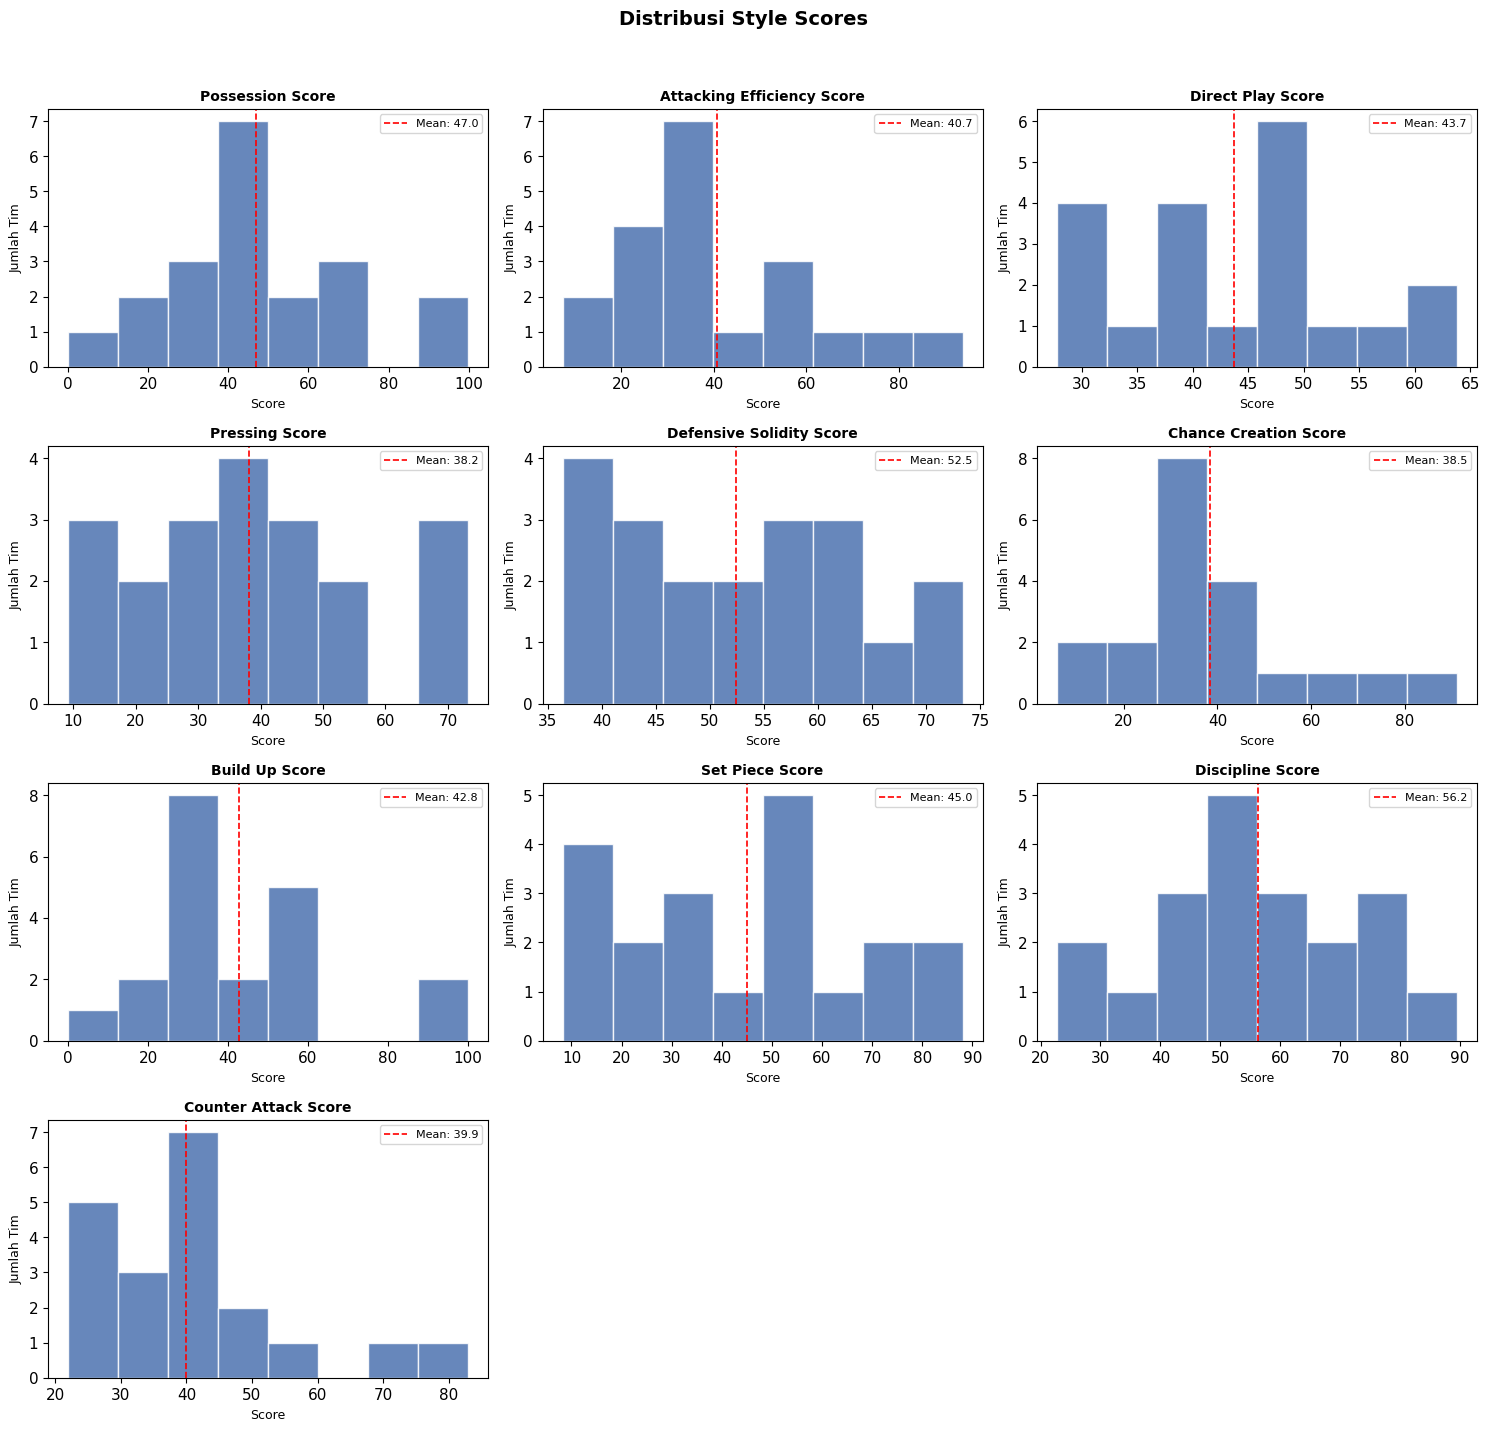

In [7]:
n_cols_grid = 3
n_rows_grid = (len(score_cols) + n_cols_grid - 1) // n_cols_grid

fig, axes = plt.subplots(n_rows_grid, n_cols_grid, figsize=(15, n_rows_grid * 3.5))
fig.suptitle("Distribusi Style Scores", fontsize=14, fontweight="bold", y=1.02)

for idx, col in enumerate(score_cols):
    ax = axes.flat[idx]
    ax.hist(df[col], bins=8, color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.axvline(df[col].mean(), color="red", linestyle="--", linewidth=1.2,
              label=f"Mean: {df[col].mean():.1f}")
    ax.set_title(col.replace("_", " ").title(), fontsize=10, fontweight="bold")
    ax.set_xlabel("Score", fontsize=9)
    ax.set_ylabel("Jumlah Tim", fontsize=9)
    ax.legend(fontsize=8)

for idx in range(len(score_cols), len(axes.flat)):
    axes.flat[idx].set_visible(False)

plt.tight_layout()
plt.show()

### 3.2 Correlation Heatmap

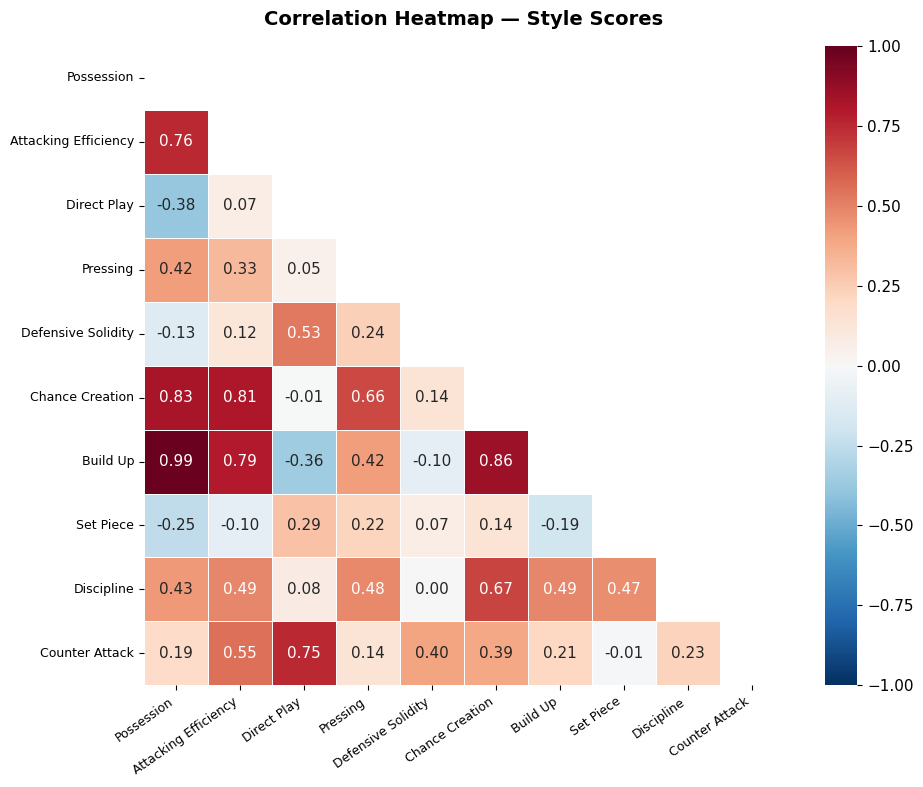

In [8]:
corr = df[score_cols].corr()
short_labels = [c.replace("_score", "").replace("_", " ").title() for c in score_cols]

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    xticklabels=short_labels, yticklabels=short_labels,
    square=True, linewidths=0.5, ax=ax,
)
ax.set_title("Correlation Heatmap — Style Scores", fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=35, ha="right", fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

---

## 4. Feature Selection

Fitur yang digunakan adalah **10 style scores**:

| No | Fitur | Deskripsi |
|----|-------|----------|
| 1 | `possession_score` | Dominasi penguasaan bola |
| 2 | `attacking_efficiency_score` | Efektivitas konversi peluang → gol |
| 3 | `direct_play_score` | Kecenderungan bermain cepat & vertikal |
| 4 | `pressing_score` | Intensitas tekanan terhadap lawan |
| 5 | `defensive_solidity_score` | Kualitas pertahanan |
| 6 | `chance_creation_score` | Kemampuan menciptakan peluang |
| 7 | `build_up_score` | Kemampuan membangun serangan bertahap |
| 8 | `set_piece_score` | Ancaman dari bola mati |
| 9 | `discipline_score` | Kedisiplinan & minimnya kesalahan |
| 10 | `counter_attack_score` | Efektivitas serangan balik |

### Mengapa Style Score?

Style scores dipilih karena merupakan **representasi terkompresi** dari puluhan indikator statistik mentah menjadi dimensi taktis yang bermakna. Setiap score sudah berada pada skala 0–100 dan memiliki interpretasi sepakbola yang jelas.

Kolom `club` tidak digunakan karena merupakan identifier, bukan variabel numerik.

In [9]:
X = df[score_cols].copy()

print(f"✅ Matriks fitur X:")
print(f"   Shape : {X.shape}")
print(f"   Fitur : {list(X.columns)}")

✅ Matriks fitur X:
   Shape : (20, 10)
   Fitur : ['possession_score', 'attacking_efficiency_score', 'direct_play_score', 'pressing_score', 'defensive_solidity_score', 'chance_creation_score', 'build_up_score', 'set_piece_score', 'discipline_score', 'counter_attack_score']


---

## 5. Feature Scaling — StandardScaler

### Mengapa Scaling Diperlukan?

GMM mengestimasi **distribusi Gaussian multivariat** untuk setiap cluster. Meskipun GMM secara teoritis dapat menangani fitur dengan skala berbeda (karena mengestimasi covariance matrix), scaling tetap direkomendasikan agar:
- Proses estimasi parameter **lebih stabil dan cepat konvergen**.
- Semua fitur berkontribusi **secara proporsional** terhadap likelihood.
- Hasil lebih **comparable** dengan K-Means pada notebook sebelumnya.

### Mengapa StandardScaler?

$$X_{scaled} = \frac{X - \mu}{\sigma}$$

StandardScaler dipilih untuk **konsistensi** dengan notebook K-Means dan karena menghasilkan distribusi yang mendekati standar normal — cocok dengan asumsi Gaussian pada GMM.

In [10]:
print("📊 SEBELUM Scaling:")
print(X.describe().round(2).loc[["mean", "std", "min", "max"]])
print()

📊 SEBELUM Scaling:
      possession_score  attacking_efficiency_score  direct_play_score  pressing_score  defensive_solidity_score  chance_creation_score  build_up_score  set_piece_score  discipline_score  \
mean             46.97                       40.71              43.74           38.19                     52.47                  38.50           42.81            44.96             56.21   
std              22.41                       21.63              10.38           18.54                     11.17                  19.77           22.93            24.94             16.29   
min               0.00                        7.37              27.77            9.16                     36.38                   5.79            0.00             8.21             22.75   
max              99.80                       93.75              63.81           73.22                     73.37                  91.06          100.00            88.06             89.50   

      counter_attack_score  
mean  

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=score_cols, index=df.index)

print("📊 SESUDAH Scaling:")
print(X_scaled_df.describe().round(2).loc[["mean", "std", "min", "max"]])

📊 SESUDAH Scaling:
      possession_score  attacking_efficiency_score  direct_play_score  pressing_score  defensive_solidity_score  chance_creation_score  build_up_score  set_piece_score  discipline_score  \
mean             -0.00                       -0.00              -0.00           -0.00                      0.00                  -0.00           -0.00             0.00             -0.00   
std               1.03                        1.03               1.03            1.03                      1.03                   1.03            1.03             1.03              1.03   
min              -2.15                       -1.58              -1.58           -1.61                     -1.48                  -1.70           -1.92            -1.51             -2.11   
max               2.42                        2.52               1.98            1.94                      1.92                   2.73            2.56             1.77              2.10   

      counter_attack_score  
mean  

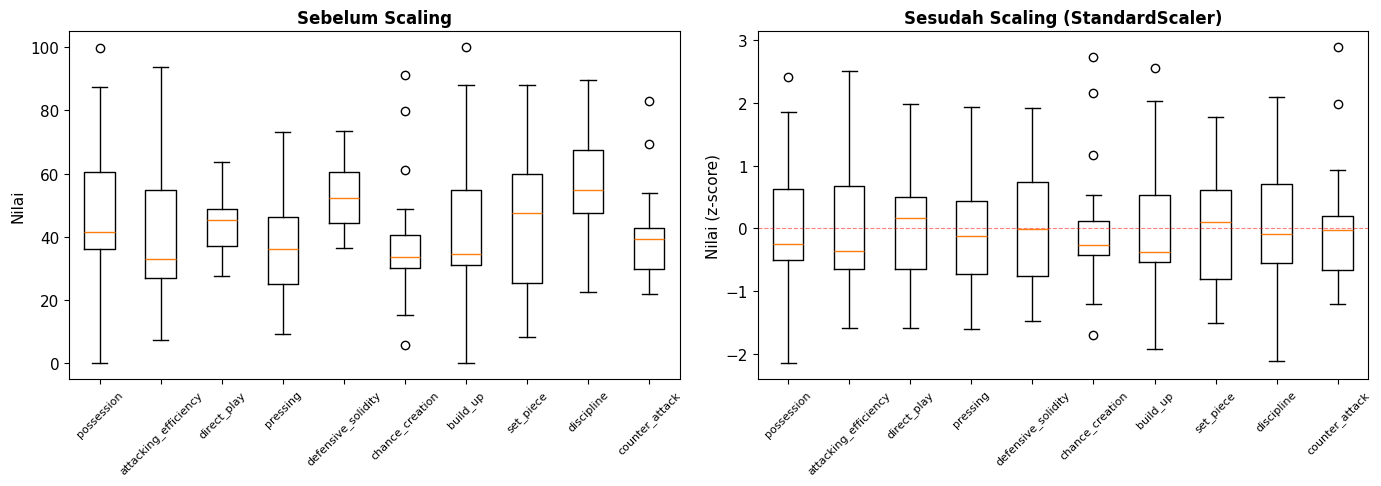

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(X.values, labels=[c.replace("_score", "") for c in score_cols], vert=True)
axes[0].set_title("Sebelum Scaling", fontsize=12, fontweight="bold")
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].set_ylabel("Nilai")

axes[1].boxplot(X_scaled, labels=[c.replace("_score", "") for c in score_cols], vert=True)
axes[1].set_title("Sesudah Scaling (StandardScaler)", fontsize=12, fontweight="bold")
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].set_ylabel("Nilai (z-score)")
axes[1].axhline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

---

## 6. Menentukan Jumlah Cluster Optimal

Untuk GMM, kita **tidak** menggunakan Elbow Method (yang berbasis inertia/WCSS milik K-Means).  
Sebagai gantinya, digunakan dua kriteria informasi yang sesuai dengan pendekatan probabilistik GMM:

### 6.1 Bayesian Information Criterion (BIC)

BIC mengukur *goodness of fit* model dengan **penalti terhadap kompleksitas** (jumlah parameter).  
Model dengan **BIC terendah** dianggap terbaik — memberikan keseimbangan antara fit dan kesederhanaan.

$$BIC = -2 \ln(L) + k \ln(n)$$

dimana $L$ = likelihood, $k$ = jumlah parameter, $n$ = jumlah sampel.

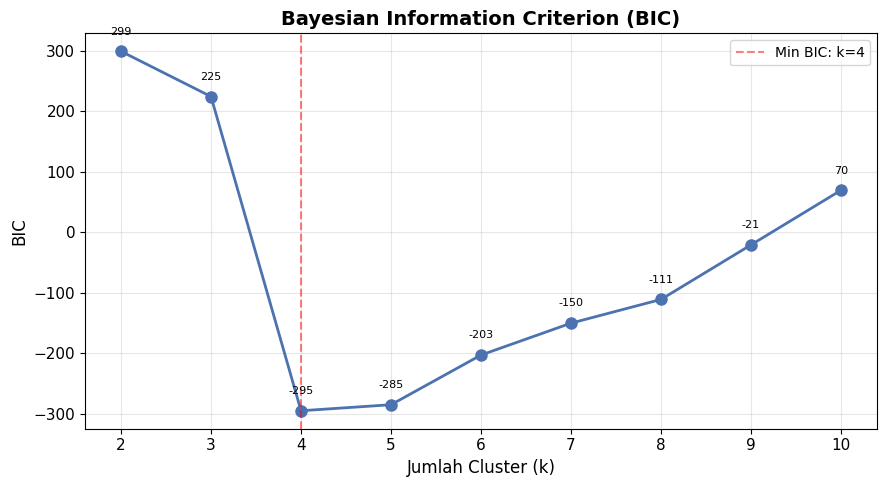


📊 BIC per k:
   k = 2  →  BIC = 299.39
   k = 3  →  BIC = 224.58
   k = 4  →  BIC = -294.85 ◀ BEST
   k = 5  →  BIC = -284.88
   k = 6  →  BIC = -202.76
   k = 7  →  BIC = -150.05
   k = 8  →  BIC = -110.81
   k = 9  →  BIC = -20.59
   k = 10  →  BIC = 69.70


In [13]:
# --- BIC & AIC ---
K_RANGE = range(2, 11)

bic_scores = []
aic_scores = []

for k in K_RANGE:
    gmm = GaussianMixture(
        n_components=k,
        random_state=RANDOM_STATE,
        covariance_type='full',
        n_init=5,
    )
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))

# --- Grafik BIC ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(K_RANGE, bic_scores, marker='o', linewidth=2, markersize=8, color='#4C72B0')
ax.set_xlabel("Jumlah Cluster (k)", fontsize=12)
ax.set_ylabel("BIC", fontsize=12)
ax.set_title("Bayesian Information Criterion (BIC)", fontsize=14, fontweight="bold")
ax.set_xticks(list(K_RANGE))
ax.grid(True, alpha=0.3)

# Highlight minimum
best_k_bic = list(K_RANGE)[np.argmin(bic_scores)]
ax.axvline(best_k_bic, color='red', linestyle='--', alpha=0.5, label=f'Min BIC: k={best_k_bic}')
ax.legend(fontsize=10)

for k, bic in zip(K_RANGE, bic_scores):
    ax.annotate(f"{bic:.0f}", (k, bic), textcoords="offset points",
                xytext=(0, 12), fontsize=8, ha='center')

plt.tight_layout()
plt.show()

print(f"\n📊 BIC per k:")
for k, bic in zip(K_RANGE, bic_scores):
    marker = " ◀ BEST" if k == best_k_bic else ""
    print(f"   k = {k}  →  BIC = {bic:.2f}{marker}")

### 6.2 Akaike Information Criterion (AIC)

AIC serupa dengan BIC tetapi memiliki **penalti yang lebih ringan** terhadap kompleksitas model.  
Model dengan **AIC terendah** dianggap terbaik.

$$AIC = -2 \ln(L) + 2k$$

AIC cenderung memilih model yang lebih kompleks dibandingkan BIC, sehingga perbandingan keduanya membantu menentukan jumlah cluster yang robust.

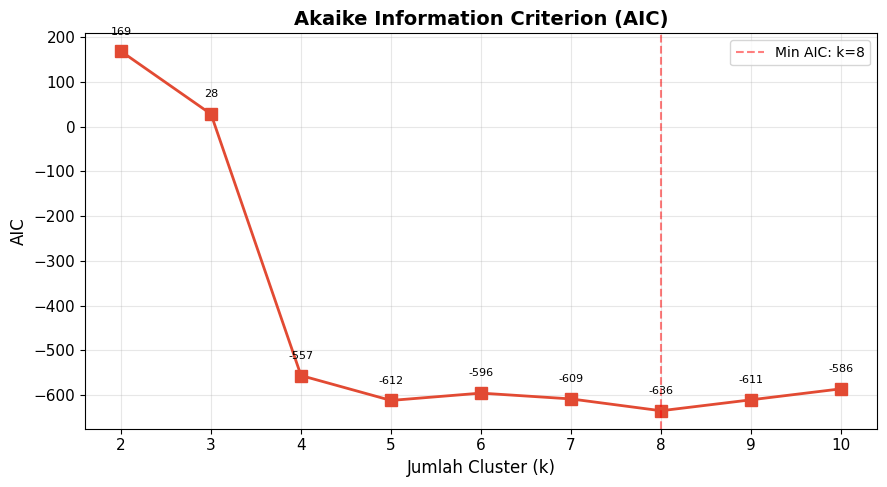


📊 AIC per k:
   k = 2  →  AIC = 168.95
   k = 3  →  AIC = 28.42
   k = 4  →  AIC = -556.73
   k = 5  →  AIC = -612.48
   k = 6  →  AIC = -596.08
   k = 7  →  AIC = -609.08
   k = 8  →  AIC = -635.56 ◀ BEST
   k = 9  →  AIC = -611.06
   k = 10  →  AIC = -586.49


In [14]:
# --- Grafik AIC ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(K_RANGE, aic_scores, marker='s', linewidth=2, markersize=8, color='#E24A33')
ax.set_xlabel("Jumlah Cluster (k)", fontsize=12)
ax.set_ylabel("AIC", fontsize=12)
ax.set_title("Akaike Information Criterion (AIC)", fontsize=14, fontweight="bold")
ax.set_xticks(list(K_RANGE))
ax.grid(True, alpha=0.3)

best_k_aic = list(K_RANGE)[np.argmin(aic_scores)]
ax.axvline(best_k_aic, color='red', linestyle='--', alpha=0.5, label=f'Min AIC: k={best_k_aic}')
ax.legend(fontsize=10)

for k, aic in zip(K_RANGE, aic_scores):
    ax.annotate(f"{aic:.0f}", (k, aic), textcoords="offset points",
                xytext=(0, 12), fontsize=8, ha='center')

plt.tight_layout()
plt.show()

print(f"\n📊 AIC per k:")
for k, aic in zip(K_RANGE, aic_scores):
    marker = " ◀ BEST" if k == best_k_aic else ""
    print(f"   k = {k}  →  AIC = {aic:.2f}{marker}")

### 6.3 Gabungan BIC & AIC

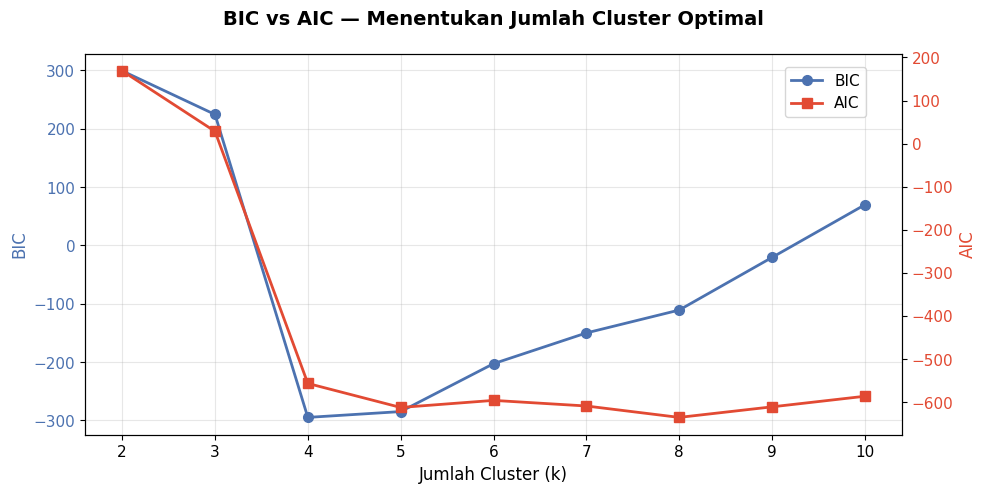


📊 Rekomendasi:
   BIC minimum pada k = 4
   AIC minimum pada k = 8


In [15]:
# --- Grafik Gabungan ---
fig, ax1 = plt.subplots(figsize=(10, 5))

color1 = '#4C72B0'
ax1.plot(K_RANGE, bic_scores, marker='o', linewidth=2, markersize=7,
         color=color1, label='BIC')
ax1.set_xlabel('Jumlah Cluster (k)', fontsize=12)
ax1.set_ylabel('BIC', fontsize=12, color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(list(K_RANGE))

ax2 = ax1.twinx()
color2 = '#E24A33'
ax2.plot(K_RANGE, aic_scores, marker='s', linewidth=2, markersize=7,
         color=color2, label='AIC')
ax2.set_ylabel('AIC', fontsize=12, color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

fig.suptitle('BIC vs AIC — Menentukan Jumlah Cluster Optimal',
             fontsize=14, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📊 Rekomendasi:")
print(f"   BIC minimum pada k = {best_k_bic}")
print(f"   AIC minimum pada k = {best_k_aic}")

In [16]:
# ============================================================
# PILIH JUMLAH CLUSTER OPTIMAL
# ============================================================
# Pertimbangkan: BIC, AIC, dan interpretabilitas.
# BIC cenderung lebih konservatif (penalti lebih besar),
# sehingga sering dijadikan acuan utama.

OPTIMAL_K = best_k_bic  # Sesuaikan jika diperlukan

print(f"✅ Jumlah cluster yang dipilih: k = {OPTIMAL_K}")

✅ Jumlah cluster yang dipilih: k = 4


---

## 7. Training Gaussian Mixture Model

GMM mengestimasi **campuran distribusi Gaussian** pada data.  
Setiap cluster dimodelkan sebagai satu distribusi Gaussian multivariat dengan **mean** dan **covariance matrix** masing-masing.

Parameter:
- `n_components` = jumlah cluster optimal
- `covariance_type = 'full'` — setiap cluster memiliki covariance matrix sendiri (paling fleksibel)
- `random_state = 42` — reproducibility
- `n_init = 5` — menjalankan estimasi 5 kali dengan inisialisasi berbeda, memilih yang terbaik

In [17]:
# --- Training GMM ---
gmm = GaussianMixture(
    n_components=OPTIMAL_K,
    covariance_type='full',
    random_state=RANDOM_STATE,
    n_init=5,
)

cluster_labels = gmm.fit_predict(X_scaled)

# Tambahkan label cluster ke dataset
df["cluster"] = cluster_labels

print(f"✅ GMM training selesai.")
print(f"   Jumlah cluster     : {OPTIMAL_K}")
print(f"   Converged          : {gmm.converged_}")
print(f"   Iterations         : {gmm.n_iter_}")
print(f"   Log-likelihood     : {gmm.score(X_scaled) * len(X_scaled):.2f}")
print(f"   BIC                : {gmm.bic(X_scaled):.2f}")
print(f"   AIC                : {gmm.aic(X_scaled):.2f}")
print(f"   Silhouette Score   : {silhouette_score(X_scaled, cluster_labels):.4f}")
print(f"\n   Distribusi cluster:")
print(df["cluster"].value_counts().sort_index().to_string())

✅ GMM training selesai.
   Jumlah cluster     : 4
   Converged          : True
   Iterations         : 2
   Log-likelihood     : 541.36
   BIC                : -294.85
   AIC                : -556.73
   Silhouette Score   : 0.2185

   Distribusi cluster:
cluster
0    3
1    7
2    6
3    4


In [18]:
# --- Hasil Clustering: Klub dan Cluster ---
print("📋 Hasil Clustering GMM:\n")
for cluster_id in sorted(df["cluster"].unique()):
    clubs = df[df["cluster"] == cluster_id]["club"].tolist()
    print(f"   Cluster {cluster_id} ({len(clubs)} klub): {', '.join(clubs)}")

📋 Hasil Clustering GMM:

   Cluster 0 (3 klub): Atlético Madrid, Barcelona, Real Madrid
   Cluster 1 (7 klub): Celta Vigo, Elche, Girona, Mallorca, Real Oviedo, Real Sociedad, Sevilla
   Cluster 2 (6 klub): Alaves, Espanyol, Getafe, Levante, Osasuna, Valencia
   Cluster 3 (4 klub): Athletic Bilbao, Rayo Vallecano, Real Betis, Villarreal


---

## 8. Probability Membership — Keunggulan Utama GMM

Ini merupakan **bagian terpenting** yang membedakan GMM dari K-Means.

Dengan `predict_proba()`, setiap klub mendapatkan **probabilitas keanggotaan** pada **setiap cluster**.  
Hal ini merepresentasikan realita sepakbola modern dimana:
- Sebuah tim bisa memiliki **identitas taktis yang dominan** (probabilitas tinggi pada satu cluster).
- Atau memiliki **karakter bermain hibrida** (probabilitas tersebar di beberapa cluster).

Interpretasi:
- **Probabilitas > 90%** → Identitas bermain sangat kuat dan konsisten pada satu gaya.
- **Probabilitas 50-70%** → Tim memiliki gaya utama tetapi sering mengadopsi elemen gaya lain.
- **Probabilitas tersebar merata** → Tim bersifat fleksibel/adaptif atau sulit dikategorikan.

In [19]:
# --- Hitung probabilitas keanggotaan ---
proba = gmm.predict_proba(X_scaled)

# Buat DataFrame probabilitas
proba_cols = [f"prob_cluster_{i}" for i in range(OPTIMAL_K)]
df_proba = pd.DataFrame(proba, columns=proba_cols)
df_proba.insert(0, "club", df["club"].values)
df_proba.insert(1, "cluster", df["cluster"].values)

# Tambahkan kolom probabilitas maksimum
df_proba["max_prob"] = proba.max(axis=1)

# Urutkan berdasarkan cluster, lalu probabilitas max (descending)
df_proba_sorted = df_proba.sort_values(["cluster", "max_prob"], ascending=[True, False])

print("📊 Probabilitas Keanggotaan Setiap Klub:\n")
df_proba_sorted.round(4).reset_index(drop=True)

📊 Probabilitas Keanggotaan Setiap Klub:



,club,cluster,prob_cluster_0,prob_cluster_1,prob_cluster_2,prob_cluster_3,max_prob
0,Atlético Madrid,0,1.00,0.00,0.00,0.00,1.00
1,Barcelona,0,1.00,0.00,0.00,0.00,1.00
2,Real Madrid,0,1.00,0.00,0.00,0.00,1.00
3,Celta Vigo,1,0.00,1.00,0.00,0.00,1.00
4,Elche,1,0.00,1.00,0.00,0.00,1.00
5,Girona,1,0.00,1.00,0.00,0.00,1.00
6,Mallorca,1,0.00,1.00,0.00,0.00,1.00
7,Real Oviedo,1,0.00,1.00,0.00,0.00,1.00
8,Real Sociedad,1,0.00,1.00,0.00,0.00,1.00
9,Sevilla,1,0.00,1.00,0.00,0.00,1.00


In [20]:
# --- Identifikasi klub dengan karakter hibrida ---
HYBRID_THRESHOLD = 0.80  # Klub dengan prob max < 80% dianggap hibrida

hybrid_clubs = df_proba[df_proba["max_prob"] < HYBRID_THRESHOLD].sort_values("max_prob")
pure_clubs = df_proba[df_proba["max_prob"] >= HYBRID_THRESHOLD].sort_values("max_prob", ascending=False)

print(f"🔀 Klub dengan Karakter HIBRIDA (prob max < {HYBRID_THRESHOLD*100:.0f}%):")
print(f"   Jumlah: {len(hybrid_clubs)} klub")
for _, row in hybrid_clubs.iterrows():
    probs_str = ", ".join([f"C{i}: {row[c]:.1%}" for i, c in enumerate(proba_cols)])
    print(f"   • {row['club']:<20s} → {probs_str}")

print(f"\n🎯 Klub dengan Identitas KUAT (prob max >= {HYBRID_THRESHOLD*100:.0f}%):")
print(f"   Jumlah: {len(pure_clubs)} klub")
for _, row in pure_clubs.iterrows():
    print(f"   • {row['club']:<20s} → Cluster {int(row['cluster'])} ({row['max_prob']:.1%})")

🔀 Klub dengan Karakter HIBRIDA (prob max < 80%):
   Jumlah: 0 klub

🎯 Klub dengan Identitas KUAT (prob max >= 80%):
   Jumlah: 20 klub
   • Alaves               → Cluster 2 (100.0%)
   • Athletic Bilbao      → Cluster 3 (100.0%)
   • Valencia             → Cluster 2 (100.0%)
   • Sevilla              → Cluster 1 (100.0%)
   • Real Sociedad        → Cluster 1 (100.0%)
   • Real Oviedo          → Cluster 1 (100.0%)
   • Real Madrid          → Cluster 0 (100.0%)
   • Real Betis           → Cluster 3 (100.0%)
   • Rayo Vallecano       → Cluster 3 (100.0%)
   • Osasuna              → Cluster 2 (100.0%)
   • Mallorca             → Cluster 1 (100.0%)
   • Levante              → Cluster 2 (100.0%)
   • Girona               → Cluster 1 (100.0%)
   • Getafe               → Cluster 2 (100.0%)
   • Espanyol             → Cluster 2 (100.0%)
   • Elche                → Cluster 1 (100.0%)
   • Celta Vigo           → Cluster 1 (100.0%)
   • Barcelona            → Cluster 0 (100.0%)
   • Atlético Madri

---

## 9. Cluster Profiling

Memahami **karakteristik dominan** setiap cluster berdasarkan rata-rata style scores.

In [21]:
cluster_profile = df.groupby("cluster")[score_cols].mean().round(2)

print("📊 Cluster Profile — Rata-rata Style Scores:\n")
cluster_profile

📊 Cluster Profile — Rata-rata Style Scores:



,possession_score,attacking_efficiency_score,direct_play_score,pressing_score,defensive_solidity_score,chance_creation_score,build_up_score,set_piece_score,discipline_score,counter_attack_score
cluster,,,,,,,,,,
0,83.83,74.49,39.37,58.85,56.38,77.37,83.27,59.97,77.87,44.54
1,50.36,35.93,35.75,29.62,42.27,29.10,44.35,26.23,45.23,30.60
2,26.27,27.76,47.42,34.21,54.08,27.38,23.28,69.54,59.71,36.50
3,44.44,43.16,55.48,43.68,64.97,42.48,39.06,29.60,53.92,57.62


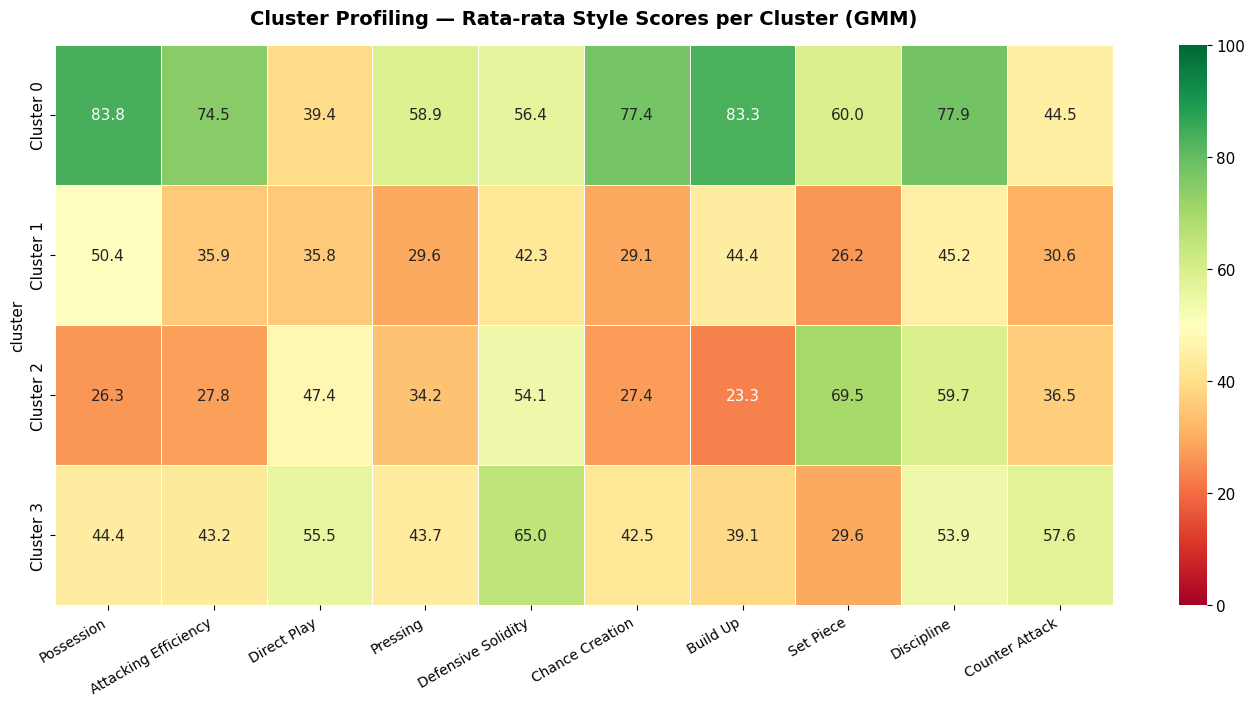

In [22]:
# --- Heatmap Cluster Profiling ---
fig, ax = plt.subplots(figsize=(14, 4 + OPTIMAL_K * 0.8))

sns.heatmap(
    cluster_profile,
    annot=True, fmt=".1f",
    cmap="RdYlGn",
    xticklabels=short_labels,
    yticklabels=[f"Cluster {i}" for i in cluster_profile.index],
    linewidths=0.5,
    vmin=0, vmax=100,
    ax=ax,
)

ax.set_title("Cluster Profiling — Rata-rata Style Scores per Cluster (GMM)",
             fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=30, ha="right", fontsize=10)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

In [23]:
# --- Interpretasi otomatis ---
print("🔍 Karakteristik Dominan per Cluster (GMM):\n")
for cluster_id in sorted(cluster_profile.index):
    row = cluster_profile.loc[cluster_id]
    top_3 = row.nlargest(3)
    bottom_3 = row.nsmallest(3)
    clubs = df[df["cluster"] == cluster_id]["club"].tolist()

    print(f"   Cluster {cluster_id} — {len(clubs)} klub: {', '.join(clubs)}")
    print(f"      🟢 Kekuatan  : {', '.join([f'{c.replace(chr(95)+chr(115)+chr(99)+chr(111)+chr(114)+chr(101), chr(0)).replace(chr(95), chr(32)).strip()} ({v:.1f})' for c, v in top_3.items()])}")
    print(f"      🔴 Kelemahan : {', '.join([f'{c.replace(chr(95)+chr(115)+chr(99)+chr(111)+chr(114)+chr(101), chr(0)).replace(chr(95), chr(32)).strip()} ({v:.1f})' for c, v in bottom_3.items()])}")
    print()

🔍 Karakteristik Dominan per Cluster (GMM):

   Cluster 0 — 3 klub: Atlético Madrid, Barcelona, Real Madrid
      🟢 Kekuatan  : possession  (83.8), build up  (83.3), discipline  (77.9)
      🔴 Kelemahan : direct play  (39.4), counter attack  (44.5), defensive solidity  (56.4)

   Cluster 1 — 7 klub: Celta Vigo, Elche, Girona, Mallorca, Real Oviedo, Real Sociedad, Sevilla
      🟢 Kekuatan  : possession  (50.4), discipline  (45.2), build up  (44.4)
      🔴 Kelemahan : set piece  (26.2), chance creation  (29.1), pressing  (29.6)

   Cluster 2 — 6 klub: Alaves, Espanyol, Getafe, Levante, Osasuna, Valencia
      🟢 Kekuatan  : set piece  (69.5), discipline  (59.7), defensive solidity  (54.1)
      🔴 Kelemahan : build up  (23.3), possession  (26.3), chance creation  (27.4)

   Cluster 3 — 4 klub: Athletic Bilbao, Rayo Vallecano, Real Betis, Villarreal
      🟢 Kekuatan  : defensive solidity  (65.0), counter attack  (57.6), direct play  (55.5)
      🔴 Kelemahan : set piece  (29.6), build up  (39

---

## 10. Visualisasi PCA — Scatter Plot

PCA mereduksi 10 dimensi style scores menjadi 2 komponen utama agar cluster dapat divisualisasikan.  
Warna setiap titik menunjukkan cluster utama yang diberikan oleh GMM.

In [24]:
# --- PCA ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

ev1 = pca.explained_variance_ratio_[0] * 100
ev2 = pca.explained_variance_ratio_[1] * 100

print(f"📐 PCA Explained Variance:")
print(f"   PC1: {ev1:.1f}%")
print(f"   PC2: {ev2:.1f}%")
print(f"   Total: {ev1 + ev2:.1f}%")

📐 PCA Explained Variance:
   PC1: 43.8%
   PC2: 23.9%
   Total: 67.7%


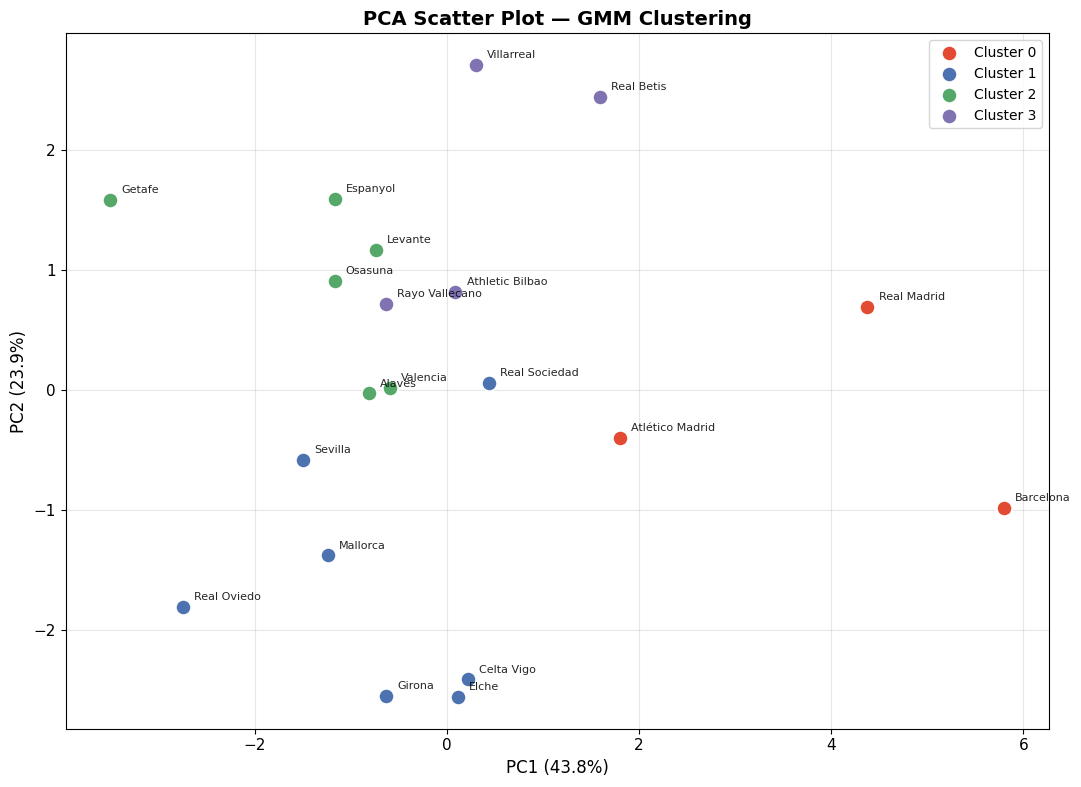

In [25]:
# --- PCA Scatter Plot ---
cluster_colors = ['#E24A33', '#4C72B0', '#55A868', '#8172B2', '#C44E52',
                  '#CCB974', '#64B5CD', '#8C8C8C', '#FF9F1C', '#2EC4B6']

fig, ax = plt.subplots(figsize=(11, 8))

for cluster_id in sorted(df["cluster"].unique()):
    mask = df["cluster"] == cluster_id
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=cluster_colors[cluster_id],
        s=120,
        label=f"Cluster {cluster_id}",
        edgecolors='white',
        linewidth=1.2,
        zorder=3,
    )

for i, club in enumerate(df["club"]):
    ax.annotate(
        club, (X_pca[i, 0], X_pca[i, 1]),
        textcoords="offset points",
        xytext=(8, 5),
        fontsize=8,
        alpha=0.85,
    )

ax.set_xlabel(f"PC1 ({ev1:.1f}%)", fontsize=12)
ax.set_ylabel(f"PC2 ({ev2:.1f}%)", fontsize=12)
ax.set_title("PCA Scatter Plot — GMM Clustering", fontsize=14, fontweight="bold")
ax.legend(fontsize=10, loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 11. Probability Heatmap

Heatmap probabilitas menampilkan **seberapa kuat** setiap klub terkait dengan setiap cluster.  
Visualisasi ini adalah ciri khas GMM (*soft clustering*) — menunjukkan bahwa beberapa klub memiliki **probabilitas tinggi pada lebih dari satu cluster**.

- **Warna gelap (mendekati 1.0)** → Klub sangat kuat terkait dengan cluster tersebut.
- **Warna terang tersebar** → Klub memiliki karakter bermain hibrida.

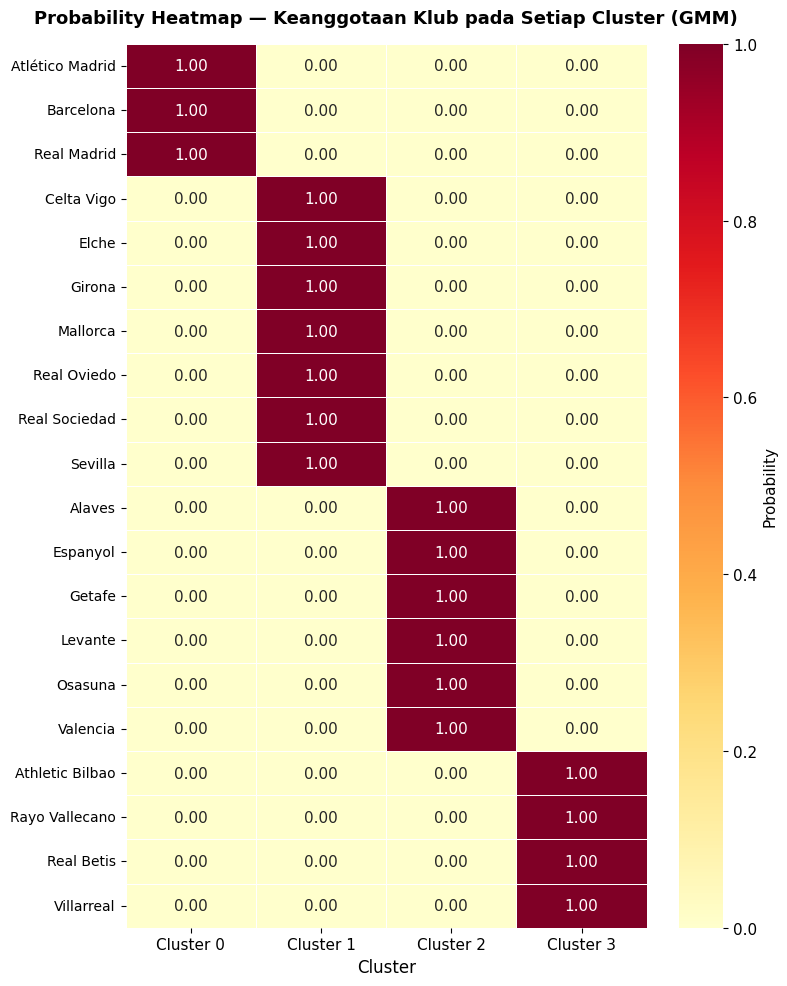

In [26]:
# --- Probability Heatmap ---
# Siapkan data heatmap
df_heatmap_proba = df_proba.set_index("club")[proba_cols].copy()
df_heatmap_proba.columns = [f"Cluster {i}" for i in range(OPTIMAL_K)]

# Urutkan berdasarkan cluster utama, lalu probabilitas max
order = df_proba.sort_values(["cluster", "max_prob"], ascending=[True, False])["club"]
df_heatmap_proba = df_heatmap_proba.loc[order]

fig, ax = plt.subplots(figsize=(8, 10))

sns.heatmap(
    df_heatmap_proba,
    annot=True, fmt=".2f",
    cmap="YlOrRd",
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Probability"},
)

ax.set_title("Probability Heatmap — Keanggotaan Klub pada Setiap Cluster (GMM)",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Cluster", fontsize=12)
ax.set_ylabel("")
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

---

## 12. Radar Chart per Cluster

Radar chart menampilkan **profil rata-rata** setiap cluster untuk memudahkan perbandingan karakteristik taktis antar cluster.

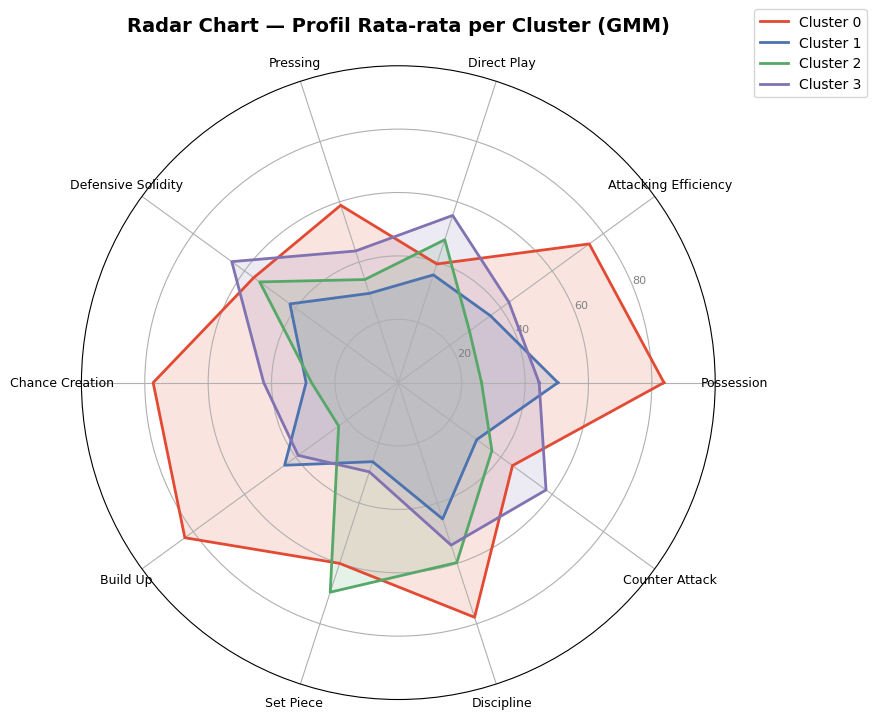

In [27]:
# --- Radar Chart: Overlay semua cluster ---
labels_radar = [c.replace("_score", "").replace("_", " ").title() for c in score_cols]
num_vars = len(score_cols)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for cluster_id in sorted(cluster_profile.index):
    values = cluster_profile.loc[cluster_id].tolist()
    values += values[:1]

    ax.fill(angles, values, alpha=0.15, color=cluster_colors[cluster_id])
    ax.plot(angles, values, linewidth=2, color=cluster_colors[cluster_id],
            label=f"Cluster {cluster_id}")

ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80])
ax.set_yticklabels(["20", "40", "60", "80"], fontsize=8, color="gray")
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_radar, fontsize=9)
ax.set_title("Radar Chart — Profil Rata-rata per Cluster (GMM)",
             fontsize=14, fontweight="bold", pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1), fontsize=10)

plt.tight_layout()
plt.show()

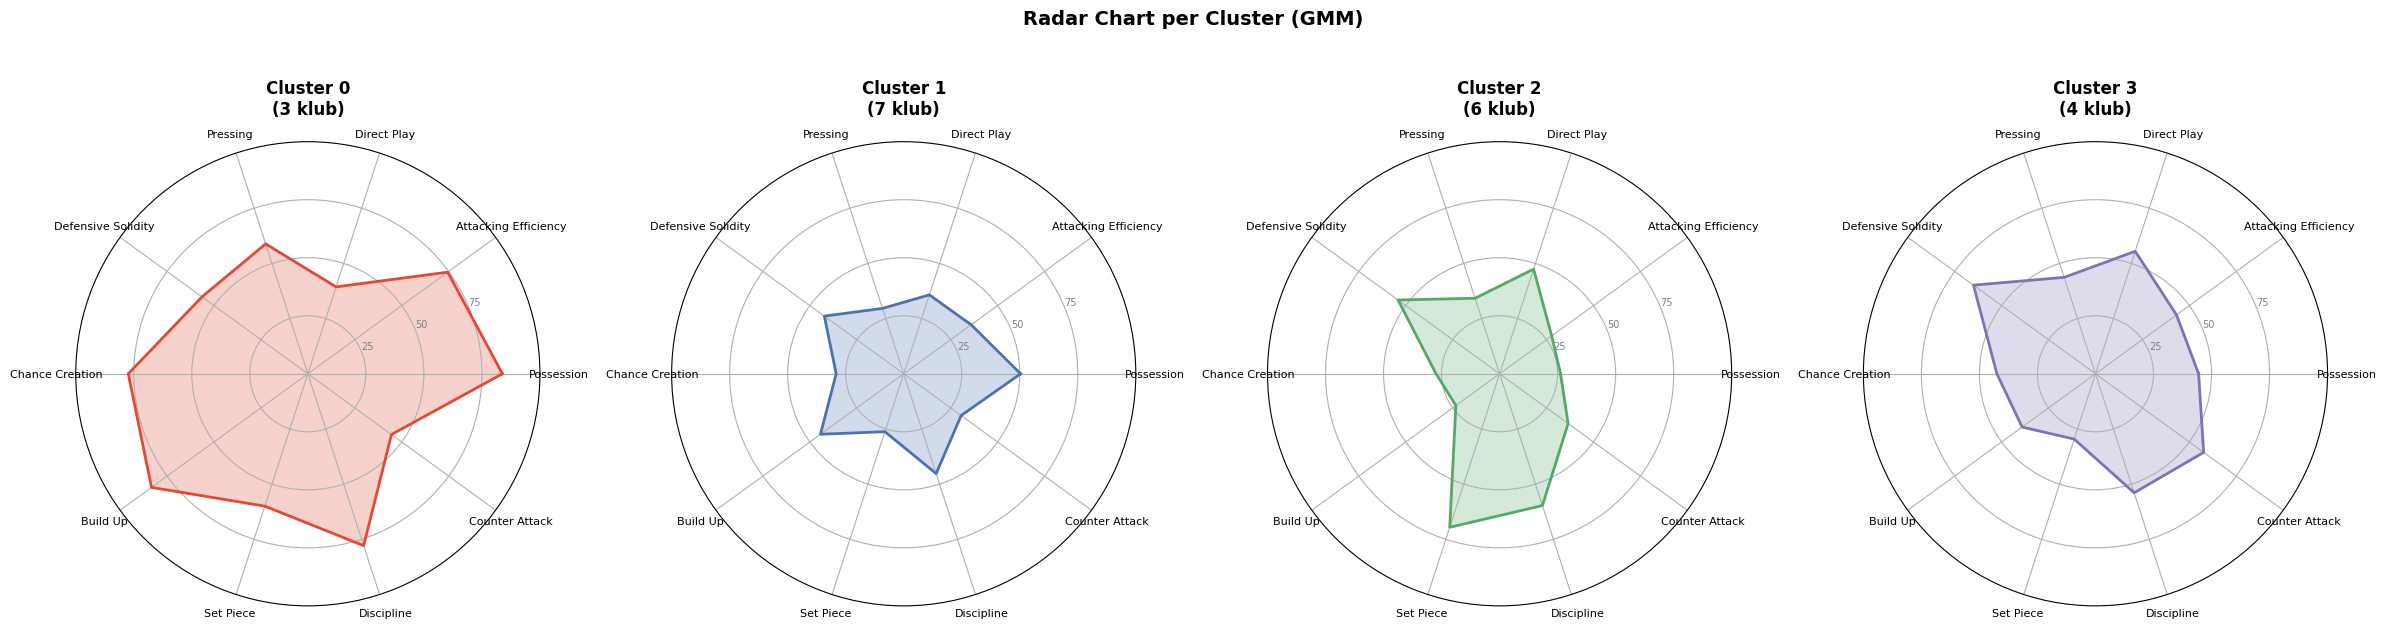

In [28]:
# --- Radar Chart: Terpisah per cluster ---
n_clusters = len(cluster_profile)
fig, axes = plt.subplots(1, n_clusters, figsize=(6 * n_clusters, 6),
                         subplot_kw=dict(polar=True))

if n_clusters == 1:
    axes = [axes]

for cluster_id, ax in zip(sorted(cluster_profile.index), axes):
    values = cluster_profile.loc[cluster_id].tolist()
    values += values[:1]
    clubs = df[df["cluster"] == cluster_id]["club"].tolist()

    ax.fill(angles, values, alpha=0.25, color=cluster_colors[cluster_id])
    ax.plot(angles, values, linewidth=2, color=cluster_colors[cluster_id])
    ax.set_ylim(0, 100)
    ax.set_yticks([25, 50, 75])
    ax.set_yticklabels(["25", "50", "75"], fontsize=7, color="gray")
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels_radar, fontsize=8)
    ax.set_title(f"Cluster {cluster_id}\n({len(clubs)} klub)",
                 fontsize=12, fontweight="bold", pad=20)

plt.suptitle("Radar Chart per Cluster (GMM)", fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

---

## 13. Analisis Klub

Detail setiap klub: cluster utama, probabilitas pada seluruh cluster, dan style scores.  
Interpretasi diberikan berdasarkan probabilitas — apakah klub memiliki identitas kuat atau bersifat hibrida.

In [29]:
# --- Tabel lengkap ---
df_full = df_proba.merge(df[["club"] + score_cols], on="club")
df_full_sorted = df_full.sort_values(["cluster", "max_prob"], ascending=[True, False])
df_full_sorted.reset_index(drop=True)

,club,cluster,prob_cluster_0,prob_cluster_1,prob_cluster_2,prob_cluster_3,max_prob,possession_score,attacking_efficiency_score,direct_play_score,pressing_score,defensive_solidity_score,chance_creation_score,build_up_score,set_piece_score,discipline_score,counter_attack_score
0,Atlético Madrid,0,1.00,0.00,0.00,0.00,1.00,64.13,58.54,38.98,35.33,58.04,61.09,61.77,51.70,70.46,33.93
1,Barcelona,0,1.00,0.00,0.00,0.00,1.00,99.80,93.75,32.82,72.06,50.73,91.06,100.00,57.58,89.50,45.88
2,Real Madrid,0,1.00,0.00,0.00,0.00,1.00,87.55,71.19,46.32,69.15,60.37,79.97,88.03,70.64,73.66,53.82
3,Celta Vigo,1,0.00,1.00,0.00,0.00,1.00,64.03,54.75,31.21,22.05,47.38,34.87,62.05,8.21,48.11,23.52
4,Elche,1,0.00,1.00,0.00,0.00,1.00,63.64,39.11,27.77,45.09,38.68,31.56,54.86,10.18,47.61,30.88
5,Girona,1,0.00,1.00,0.00,0.00,1.00,59.66,26.94,30.45,14.34,37.45,30.88,54.86,21.89,55.24,26.44
6,Mallorca,1,0.00,1.00,0.00,0.00,1.00,37.97,36.99,38.78,16.19,36.38,26.22,33.78,26.67,58.14,31.05
7,Real Oviedo,1,0.00,1.00,0.00,0.00,1.00,37.79,7.37,30.42,17.83,43.52,15.25,31.16,52.04,30.59,21.94
8,Real Sociedad,1,0.00,1.00,0.00,0.00,1.00,48.62,55.61,47.06,51.23,44.52,39.71,40.27,51.50,54.18,39.86
9,Sevilla,1,0.00,1.00,0.00,0.00,1.00,40.83,30.74,44.58,40.62,47.93,25.21,33.48,13.10,22.75,40.48


In [30]:
# --- Analisis per klub ---
print("📋 Analisis Klub — GMM Clustering")
print("=" * 90)

for cluster_id in sorted(df["cluster"].unique()):
    cluster_data = df_proba[df_proba["cluster"] == cluster_id].sort_values(
        "max_prob", ascending=False
    )
    cluster_mean = cluster_profile.loc[cluster_id]
    top_style = cluster_mean.idxmax().replace("_score", "").replace("_", " ").title()

    print(f"\n── Cluster {cluster_id} (Ciri utama: {top_style}) ──\n")

    for _, row in cluster_data.iterrows():
        club = row["club"]
        max_p = row["max_prob"]

        # Probabilitas pada setiap cluster
        probs = [(i, row[c]) for i, c in enumerate(proba_cols)]
        probs_sorted = sorted(probs, key=lambda x: x[1], reverse=True)
        probs_str = ", ".join([f"C{p[0]}: {p[1]:.0%}" for p in probs_sorted if p[1] > 0.01])

        # Status: murni atau hibrida
        if max_p >= 0.90:
            status = "🎯 Identitas sangat kuat"
        elif max_p >= 0.70:
            status = "✅ Identitas kuat"
        elif max_p >= 0.50:
            status = "🔀 Karakter hibrida"
        else:
            status = "⚠️ Sangat fleksibel/ambigu"

        # Keunggulan dari style scores
        club_scores = df[df["club"] == club][score_cols].iloc[0]
        top_2_scores = club_scores.nlargest(2)
        strengths = ", ".join([f"{c.replace('_score', '').replace('_', ' ').title()} ({v:.1f})"
                              for c, v in top_2_scores.items()])

        print(f"   • {club:<20s} │ {status}")
        print(f"     Probabilitas    : {probs_str}")
        print(f"     Keunggulan      : {strengths}")
        print()

print("=" * 90)

📋 Analisis Klub — GMM Clustering

── Cluster 0 (Ciri utama: Possession) ──

   • Atlético Madrid      │ 🎯 Identitas sangat kuat
     Probabilitas    : C0: 100%
     Keunggulan      : Discipline (70.5), Possession (64.1)

   • Barcelona            │ 🎯 Identitas sangat kuat
     Probabilitas    : C0: 100%
     Keunggulan      : Build Up (100.0), Possession (99.8)

   • Real Madrid          │ 🎯 Identitas sangat kuat
     Probabilitas    : C0: 100%
     Keunggulan      : Build Up (88.0), Possession (87.5)


── Cluster 1 (Ciri utama: Possession) ──

   • Celta Vigo           │ 🎯 Identitas sangat kuat
     Probabilitas    : C1: 100%
     Keunggulan      : Possession (64.0), Build Up (62.0)

   • Elche                │ 🎯 Identitas sangat kuat
     Probabilitas    : C1: 100%
     Keunggulan      : Possession (63.6), Build Up (54.9)

   • Girona               │ 🎯 Identitas sangat kuat
     Probabilitas    : C1: 100%
     Keunggulan      : Possession (59.7), Discipline (55.2)

   • Mallorca     

---

## 14. Perbandingan dengan K-Means

Setelah menjalankan GMM, penting untuk memahami perbedaannya dengan K-Means yang telah dijalankan pada notebook sebelumnya.

### Perbedaan Konseptual

| Aspek | K-Means | GMM |
|-------|---------|-----|
| **Tipe Clustering** | Hard Clustering | Soft Clustering |
| **Output** | Satu label cluster per sampel | Probabilitas keanggotaan pada setiap cluster |
| **Asumsi Bentuk Cluster** | Spherical (bulat, ukuran sama) | Ellipsoidal (bentuk dan ukuran bebas) |
| **Metrik Jarak** | Euclidean Distance | Mahalanobis Distance (implisit via covariance) |
| **Metode Optimasi** | Minimize WCSS (inertia) | Maximize Log-Likelihood (EM algorithm) |
| **Pemilihan k** | Elbow + Silhouette | BIC + AIC |
| **Interpretabilitas** | Sederhana: "Klub X masuk Cluster Y" | Lebih kaya: "Klub X 60% Cluster A, 35% Cluster B" |

### Kelebihan & Kekurangan

| | K-Means | GMM |
|--|---------|-----|
| **Kelebihan** | Cepat, sederhana, mudah dijelaskan | Probabilistik, fleksibel, bentuk cluster bebas |
| **Kekurangan** | Cluster harus berbentuk bulat, hard assignment | Lebih lambat, risiko overfitting pada data kecil |

### Kapan Menggunakan Masing-masing?

| Skenario | Rekomendasi |
|----------|------------|
| Data besar, butuh hasil cepat | **K-Means** |
| Cluster berbentuk bulat dan terpisah jelas | **K-Means** |
| Ingin tahu probabilitas keanggotaan | **GMM** |
| Cluster berbentuk elips atau overlap | **GMM** |
| Analisis karakter hibrida/campuran | **GMM** |
| Presentasi untuk stakeholder non-teknis | **K-Means** (lebih mudah dipahami) |
| Riset akademis yang butuh nuansa probabilistik | **GMM** |

### Kesimpulan Perbandingan

Untuk analisis gaya bermain sepakbola, **GMM lebih sesuai** karena:
1. Tim sepakbola modern jarang bermain dengan gaya yang 100% murni satu kategori.
2. Probabilitas keanggotaan GMM merepresentasikan **fleksibilitas taktis** yang nyata — misalnya Real Madrid bisa bermain possession di satu pertandingan dan direct play di pertandingan lain.
3. Informasi probabilitas memberikan **insight yang lebih kaya** untuk analisis dan dashboard.

Namun, **K-Means tetap berguna** sebagai langkah awal dan validasi silang karena hasilnya lebih mudah dikomunikasikan.

---

## 15. Simpan Hasil

In [31]:
# --- Simpan dataset dengan cluster + probabilitas ---
output_dir = PROJECT_ROOT / "data" / "ml_ready"

# Dataset 1: Cluster + scores
df_output = df[["club", "cluster"] + score_cols].sort_values("club")
path1 = output_dir / "teams_clustered_gmm.csv"
df_output.to_csv(path1, index=False)
print(f"✅ Cluster labels disimpan: {path1.name}")

# Dataset 2: Probabilitas keanggotaan
df_proba_output = df_proba.sort_values("club")
path2 = output_dir / "teams_cluster_probabilities.csv"
df_proba_output.to_csv(path2, index=False)
print(f"✅ Probabilitas disimpan  : {path2.name}")

print(f"\n📦 Output:")
print(f"   {path1.name}: {df_output.shape}")
print(f"   {path2.name}: {df_proba_output.shape}")

✅ Cluster labels disimpan: teams_clustered_gmm.csv
✅ Probabilitas disimpan  : teams_cluster_probabilities.csv

📦 Output:
   teams_clustered_gmm.csv: (20, 12)
   teams_cluster_probabilities.csv: (20, 7)


---

## 16. Kesimpulan

### Hasil Clustering GMM

Gaussian Mixture Model berhasil mengelompokkan 20 klub La Liga berdasarkan 10 dimensi gaya bermain, dengan keunggulan utama berupa **probabilitas keanggotaan** yang merepresentasikan karakter bermain tim secara lebih realistis.

### Temuan Utama

1. **Jumlah cluster optimal** ditentukan berdasarkan kombinasi BIC dan AIC.
2. **Probabilitas keanggotaan** menunjukkan bahwa beberapa klub memiliki **karakter bermain hibrida** — tidak murni satu gaya, melainkan campuran dari beberapa gaya bermain. Hal ini sesuai dengan realita sepakbola modern.
3. **Klub dengan identitas kuat** (probabilitas > 90%) menunjukkan konsistensi gaya bermain sepanjang musim.
4. **Klub dengan karakter hibrida** menunjukkan adaptabilitas taktis atau ketidakkonsistean performa.

### Pemanfaatan Hasil

1. **Dashboard Analitik** — Menampilkan probabilitas keanggotaan setiap klub secara interaktif, memungkinkan analisis karakter bermain yang lebih mendalam.
2. **Analisis Gaya Bermain** — Mengidentifikasi tidak hanya gaya bermain dominan, tetapi juga seberapa "murni" atau "campuran" karakter taktis sebuah tim.
3. **Scouting & Strategi** — Tim pelatih dapat memahami bahwa lawan tidak hanya bermain dengan satu gaya tetap, melainkan memiliki probabilitas bermain dengan gaya alternatif.

### File Output
- `teams_clustered_gmm.csv` — Dataset final berisi club, cluster label, dan 10 style scores.
- `teams_cluster_probabilities.csv` — Dataset probabilitas keanggotaan setiap klub pada setiap cluster.